<a href="https://colab.research.google.com/github/Alian-123/Machine-Learning-project/blob/main/DECISION_TREE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**HEART DISEASE PREDICTION**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [15]:
df = pd.read_csv("/content/archive (7).zip")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [17]:
# DATA UNDERSTANDING
df.info()
df.describe()
df['num'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,count
num,
0,411
1,265
2,109
3,107
4,28


In [20]:
X = df.drop('num', axis=1)
y = df['num']

In [22]:
# TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
model = DecisionTreeClassifier(max_depth=4)

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include='object').columns

# Apply one-hot encoding to training and test sets
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align columns - ensure both sets have the same columns after encoding
train_cols = X_train_encoded.columns
X_test_encoded = X_test_encoded.reindex(columns = train_cols, fill_value=0)

# Impute missing numerical values (Decision Trees cannot handle NaNs)
# Identify numerical columns that might have NaNs (excluding 'id' and encoded ones)
numerical_cols_with_nans = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

for col in numerical_cols_with_nans:
    if col in X_train_encoded.columns:
        median_val = X_train_encoded[col].median()
        X_train_encoded[col] = X_train_encoded[col].fillna(median_val)
        X_test_encoded[col] = X_test_encoded[col].fillna(median_val)

# Drop the 'id' column as it's an identifier and not a feature
if 'id' in X_train_encoded.columns:
    X_train_encoded = X_train_encoded.drop('id', axis=1)
if 'id' in X_test_encoded.columns:
    X_test_encoded = X_test_encoded.drop('id', axis=1)

model.fit(X_train_encoded, y_train)

DecisionTreeClassifier(max_depth=4)

In [53]:
#PREDICTION
y_pred = model.predict(X_test_encoded)

In [58]:
from dtreeviz import model as dtv_model
from sklearn.tree import DecisionTreeClassifier # Import for re-initialization

# Re-initialize and re-fit the model to ensure its state is fresh and correct for dtreeviz
# This step helps to guard against potential issues where the model's state might be
# unexpectedly altered or a cached version is being used by dtreeviz internally.
temp_model = DecisionTreeClassifier(max_depth=1) # Re-create the model
temp_model.fit(X_train_encoded, y_train) # Re-fit it with the correct data

m = dtv_model(
    temp_model, # Use the freshly fitted model
    X_train=X_train_encoded,
    y_train=y_train,
    feature_names=X_train_encoded.columns,
    target_name="Heart Disease",
    class_names=["No Disease", "Disease Type 1", "Disease Type 2", "Disease Type 3", "Disease Type 4"]
)

m.view()

ValueError: operands could not be broadcast together with shapes (5,) (2,) 

In [56]:
#EVALUATION
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.527363184079602
[[60 35]
 [60 46]]
              precision    recall  f1-score   support

           0       0.50      0.63      0.56        95
           1       0.57      0.43      0.49       106

    accuracy                           0.53       201
   macro avg       0.53      0.53      0.53       201
weighted avg       0.54      0.53      0.52       201



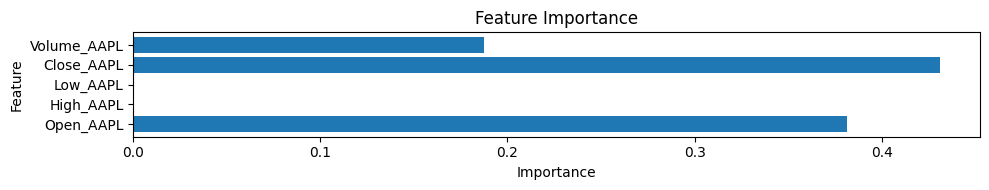

In [59]:
# VISUALISATION

importances = model.feature_importances_

# Flatten MultiIndex columns to single strings for plotting
if isinstance(X_train_encoded.columns, pd.MultiIndex):
    features = ['_'.join(col).strip() if isinstance(col, tuple) else str(col) for col in X_train_encoded.columns.values]
else:
    features = X_train_encoded.columns

plt.figure(figsize=(10, len(features) * 0.4)) # Adjust figure size based on number of features
plt.barh(features, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

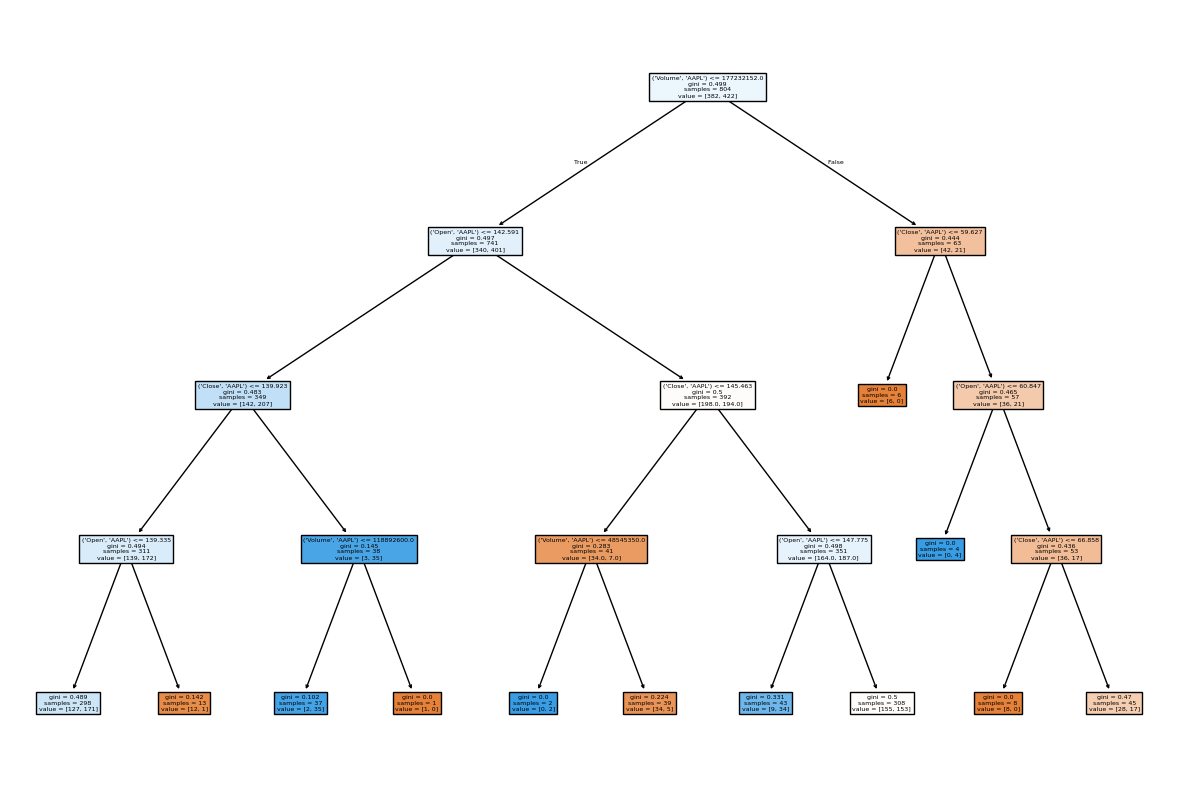

In [60]:
# DECISION TREE VISUALISATION

from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X_train_encoded.columns, filled=True) # Corrected to use encoded feature names
plt.show()